In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
import gsw

Load in all files

In [2]:
ctd11 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_011_nav.csv')
ctd13 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_013_nav2.csv')
ctd19 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_019_nav2.csv')
h2s = pd.read_excel("/Users/Sam/Documents/Postdoc/Science Paper/Geroge's figure/CTD19-Echem-AllScans.xlsx")
ctd16 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_016_nav.csv')
ctd17 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_017_nav.csv')
ctd15 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_015_nav.csv')
ctd14 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_014_full_nav.csv')

Filtering the data

In [20]:
def filter_data(data):
    data.loc[data['altitude'] < 0.1, 'altitude'] = np.nan
    data = data.loc[data['depth'] >=600]
    downcast = data.loc[:data['altitude'].idxmin()].copy().reset_index()
    downcast = downcast.loc[:downcast['depth'].idxmax()].copy()
    downcast['beam_attenuation'] = downcast['beam_transmission'].max() - downcast['beam_transmission']
    downcast.loc[downcast['pottemp'] < 0.01] = np.nan
    downcast = downcast.loc[downcast['depth'] > 1300]
    return downcast

In [21]:
ctd_files = {'ctd11': ctd11, 'ctd13': ctd13, 'ctd14': ctd14, 
             'ctd15': ctd15, 'ctd16': ctd16, 'ctd17': ctd17, 'ctd19': ctd19}

for name, data in ctd_files.items():
    globals()[f"{name}_dc"] = filter_data(data)

In [123]:
temp = ctd17.loc[:ctd17['altitude'].idxmin()].copy().reset_index()
temp = temp.loc[:temp['depth'].idxmax()].copy()

In [22]:
window_width = 300
min_obs = 1

def smooth_data(data, column:str):
    median = data[column].rolling(window=window_width, center=True, min_periods=min_obs).median()
    dif = data[column] - median

    data_med = data.copy()
    data_med[column] = data[column].where(dif.abs() <= 0.5, other=np.nan)

    data_sm = data_med.copy()
    data_sm[column] = data_med[column].interpolate(method='linear', limit_direction='forward')

    return data_sm

columns_to_smooth = ['oxygenumolkg']

ctd_dc = {'ctd11': ctd11_dc, 'ctd13': ctd13_dc, 'ctd14': ctd14_dc,
          'ctd15': ctd15_dc, 'ctd16': ctd16_dc, 'ctd17': ctd17_dc, 'ctd19': ctd19_dc}

ctd_smoothed = {}
for name, data in ctd_dc.items():
    smoothed = data.copy()
    for col in columns_to_smooth:
        smoothed = smooth_data(smoothed, col)
    ctd_smoothed[name] = smoothed

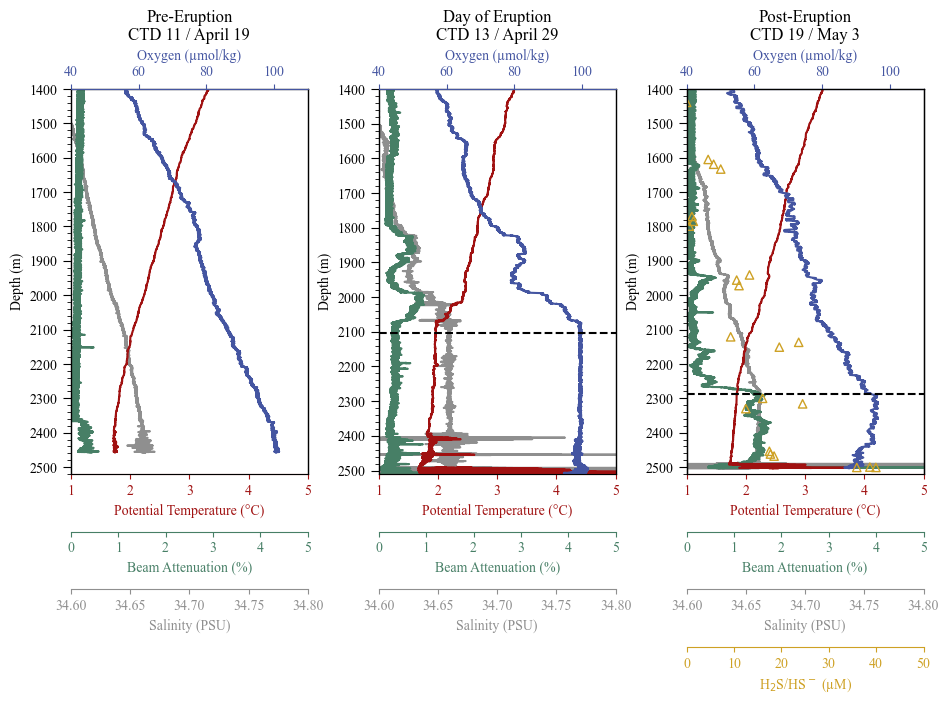

In [23]:
ctd11_p = ctd_smoothed['ctd11']
ctd13_p = ctd_smoothed['ctd13']
ctd19_p = ctd_smoothed['ctd19']

colors = ['#4455A1',"#A01111","#477F66","#8F8F8F","#CEA124"]

fig = plt.figure(figsize=(11, 5))

plt.rcParams['font.family'] = 'Times New Roman'

ax11_o2 = fig.add_subplot(1, 3, 1)

ax11_o2.plot(ctd11_p['oxygenumolkg'],ctd11_p['depth'], color=colors[0])
ax11_o2.set_ylabel('Depth (m)')
ax11_o2.set_xlim(40,110)
ax11_o2.set_ylim(2520,1400)
ax11_o2.xaxis.tick_top()
ax11_o2.xaxis.set_label_position('top')
ax11_o2.set_xlabel('Oxygen (µmol/kg)',color=colors[0])
ax11_o2.set_yticks([1400, 1500, 1600, 1700, 1800, 1900, 2000,2100,2200,2300,2400,2500])
ax11_o2.yaxis.set_minor_locator(MultipleLocator(20))
ax11_o2.tick_params(axis='y', which='minor', length=3)
ax11_o2.tick_params(axis='y', which='major', length=6)
ax11_o2.set_zorder(3.5)
ax11_o2.patch.set_visible(False)

ax11_temp = ax11_o2.twiny()
ax11_temp.plot(ctd11_p['pottemp'],ctd11_p['depth'],c=colors[1])
ax11_temp.xaxis.set_label_position('bottom')
ax11_temp.set_xlabel('Potential Temperature (°C)',color=colors[1])
ax11_temp.set_xlim(1,5)
ax11_temp.xaxis.tick_bottom()
ax11_temp.spines['bottom'].set_color(colors[1])
ax11_temp.tick_params(axis='x', colors=colors[1])
ax11_temp.set_zorder(3.4)
ax11_temp.patch.set_visible(False)

ax11_ba = ax11_o2.twiny()
ax11_ba.plot(ctd11_p['beam_attenuation'],ctd11_p['depth'],c=colors[2])
ax11_ba.xaxis.set_label_position('bottom')
ax11_ba.set_xlabel('Beam Attenuation (%)',color=colors[2])
ax11_ba.set_xlim(0,5)
ax11_ba.xaxis.tick_bottom()
ax11_ba.spines['bottom'].set_position(('axes', -0.15))
ax11_ba.spines['bottom'].set_color(colors[2])
ax11_ba.tick_params(axis='x', colors=colors[2])
ax11_ba.set_zorder(3.3)
ax11_ba.patch.set_visible(False)

ax11_sal = ax11_o2.twiny()
ax11_sal.plot(ctd11_p['salinity'],ctd11_p['depth'],c=colors[3])
ax11_sal.xaxis.set_label_position('bottom')
ax11_sal.set_xlabel('Salinity (PSU)',color=colors[3])
ax11_sal.set_xlim(34.6,34.8)
ax11_sal.xaxis.tick_bottom()
ax11_sal.spines['bottom'].set_position(('axes', -0.3))
ax11_sal.spines['bottom'].set_color(colors[3])
ax11_sal.tick_params(axis='x', colors=colors[3])
ax11_sal.set_zorder(3.2)
ax11_sal.patch.set_visible(False)

ax11_o2.xaxis.tick_top()
ax11_o2.spines['top'].set_color(colors[0])
ax11_o2.tick_params(axis='x', colors=colors[0])

ax11_o2.set_title('Pre-Eruption\nCTD 11 / April 19')


ax13_o2 = fig.add_subplot(1, 3, 2)

ax13_o2.plot(ctd13_p['oxygenumolkg'],ctd13_p['depth'], color=colors[0])
ax13_o2.set_ylim(2520,1400)
ax13_o2.set_ylabel('Depth (m)')
ax13_o2.set_xlim(40,110)
ax13_o2.set_ylim(2510,1400)
ax13_o2.xaxis.tick_top()
ax13_o2.xaxis.set_label_position('top')
ax13_o2.set_xlabel('Oxygen (µmol/kg)',color=colors[0])
ax13_o2.set_yticks([1400, 1500, 1600, 1700, 1800, 1900, 2000,2100,2200,2300,2400,2500])
ax13_o2.yaxis.set_minor_locator(MultipleLocator(20))
ax13_o2.tick_params(axis='y', which='minor', length=3)
ax13_o2.tick_params(axis='y', which='major', length=6)
ax13_o2.set_zorder(3.5)
ax13_o2.patch.set_visible(False)

ax13_temp = ax13_o2.twiny()
ax13_temp.plot(ctd13_p['pottemp'],ctd13_p['depth'],c=colors[1])
ax13_temp.xaxis.set_label_position('bottom')
ax13_temp.set_xlabel('Potential Temperature (°C)',color=colors[1])
ax13_temp.set_xlim(1,5)
ax13_temp.xaxis.tick_bottom()
ax13_temp.spines['bottom'].set_color(colors[1])
ax13_temp.tick_params(axis='x', colors=colors[1])
ax13_temp.set_zorder(3.4)
ax13_temp.patch.set_visible(False)

ax13_ba = ax13_o2.twiny()
ax13_ba.plot(ctd13_p['beam_attenuation'],ctd13_p['depth'],c=colors[2])
ax13_ba.xaxis.set_label_position('bottom')
ax13_ba.set_xlabel('Beam Attenuation (%)',color=colors[2])
ax13_ba.set_xlim(0,5)
ax13_ba.xaxis.tick_bottom()
ax13_ba.spines['bottom'].set_position(('axes', -0.15))
ax13_ba.spines['bottom'].set_color(colors[2])
ax13_ba.tick_params(axis='x', colors=colors[2])
ax13_ba.set_zorder(3.3)
ax13_ba.patch.set_visible(False)

ax13_sal = ax13_o2.twiny()
ax13_sal.plot(ctd13_p['salinity'],ctd13_p['depth'],c=colors[3])
ax13_sal.xaxis.set_label_position('bottom')
ax13_sal.set_xlabel('Salinity (PSU)',color=colors[3])
ax13_sal.set_xlim(34.6,34.8)
ax13_sal.xaxis.tick_bottom()
ax13_sal.spines['bottom'].set_position(('axes', -0.3))
ax13_sal.spines['bottom'].set_color(colors[3])
ax13_sal.tick_params(axis='x', colors=colors[3])
ax13_sal.set_zorder(3.2)
ax13_sal.patch.set_visible(False)

ax13_o2.xaxis.tick_top()
ax13_o2.spines['top'].set_color(colors[0])
ax13_o2.tick_params(axis='x', colors=colors[0])

ax13_o2.hlines(2105, 40, 110, linestyles='dashed', colors='k')

ax13_o2.set_title('Day of Eruption\nCTD 13 / April 29')


ax19_o2 = fig.add_subplot(1, 3, 3)

ax19_o2.plot(ctd19_p['oxygenumolkg'],ctd19_p['depth'], color=colors[0])
ax19_o2.set_ylim(2520,1400)
ax19_o2.set_ylabel('Depth (m)')
ax19_o2.set_xlim(40,110)
ax19_o2.set_ylim(2520,1400)
ax19_o2.xaxis.tick_top()
ax19_o2.xaxis.set_label_position('top')
ax19_o2.set_xlabel('Oxygen (µmol/kg)',color=colors[0])
ax19_o2.set_yticks([1400, 1500, 1600, 1700, 1800, 1900, 2000,2100,2200,2300,2400,2500])
ax19_o2.yaxis.set_minor_locator(MultipleLocator(20))
ax19_o2.tick_params(axis='y', which='minor', length=3)
ax19_o2.tick_params(axis='y', which='major', length=6)
ax19_o2.set_zorder(3.5)
ax19_o2.patch.set_visible(False)

ax19_temp = ax19_o2.twiny()
ax19_temp.plot(ctd19_p['pottemp'],ctd19_p['depth'],c=colors[1])
ax19_temp.xaxis.set_label_position('bottom')
ax19_temp.set_xlabel('Potential Temperature (°C)',color=colors[1])
ax19_temp.set_xlim(1,5)
ax19_temp.xaxis.tick_bottom()
ax19_temp.spines['bottom'].set_color(colors[1])
ax19_temp.tick_params(axis='x', colors=colors[1])
ax19_temp.set_zorder(3.4)
ax19_temp.patch.set_visible(False)

ax19_ba = ax19_o2.twiny()
ax19_ba.plot(ctd19_p['beam_attenuation'],ctd19_p['depth'],c=colors[2])
ax19_ba.xaxis.set_label_position('bottom')
ax19_ba.set_xlabel('Beam Attenuation (%)',color=colors[2])
ax19_ba.set_xlim(0,5)
ax19_ba.xaxis.tick_bottom()
ax19_ba.spines['bottom'].set_position(('axes', -0.15))
ax19_ba.spines['bottom'].set_color(colors[2])
ax19_ba.tick_params(axis='x', colors=colors[2])
ax19_ba.set_zorder(3.3)
ax19_ba.patch.set_visible(False)

ax19_sal = ax19_o2.twiny()
ax19_sal.plot(ctd19_p['salinity'],ctd19_p['depth'],c=colors[3])
ax19_sal.xaxis.set_label_position('bottom')
ax19_sal.set_xlabel('Salinity (PSU)',color=colors[3])
ax19_sal.set_xlim(34.6,34.8)
ax19_sal.xaxis.tick_bottom()
ax19_sal.spines['bottom'].set_position(('axes', -0.3))
ax19_sal.spines['bottom'].set_color(colors[3])
ax19_sal.tick_params(axis='x', colors=colors[3])
ax19_sal.set_zorder(3.2)
ax19_sal.patch.set_visible(False)

axh2s = ax19_o2.twiny()
axh2s.scatter(h2s['H2S, uM'],h2s['Depth'],marker='^',facecolors='none',edgecolors=colors[4],linewidths=1)
axh2s.xaxis.set_label_position('bottom')
axh2s.set_xlabel('H$_2$S/HS$^-$ (µM)', color=colors[4])
axh2s.set_xlim(0, 50)
axh2s.xaxis.tick_bottom()
axh2s.spines['bottom'].set_position(('axes', -0.45))
axh2s.spines['bottom'].set_color(colors[4])
axh2s.tick_params(axis='x', colors=colors[4])
axh2s.set_zorder(3.6)
axh2s.patch.set_visible(False)

ax19_o2.xaxis.tick_top()
ax19_o2.spines['top'].set_color(colors[0])
ax19_o2.tick_params(axis='x', colors=colors[0])

ax19_o2.hlines(2287, 40, 110, linestyles='dashed', colors='k')

ax19_o2.set_title('Post-Eruption\nCTD 19 / May 3')

plt.subplots_adjust(wspace=0.3)

plt.savefig('CTD Pre_dayof_Post Eruption O2 smoothed.pdf',format='pdf', bbox_inches='tight', dpi=300)

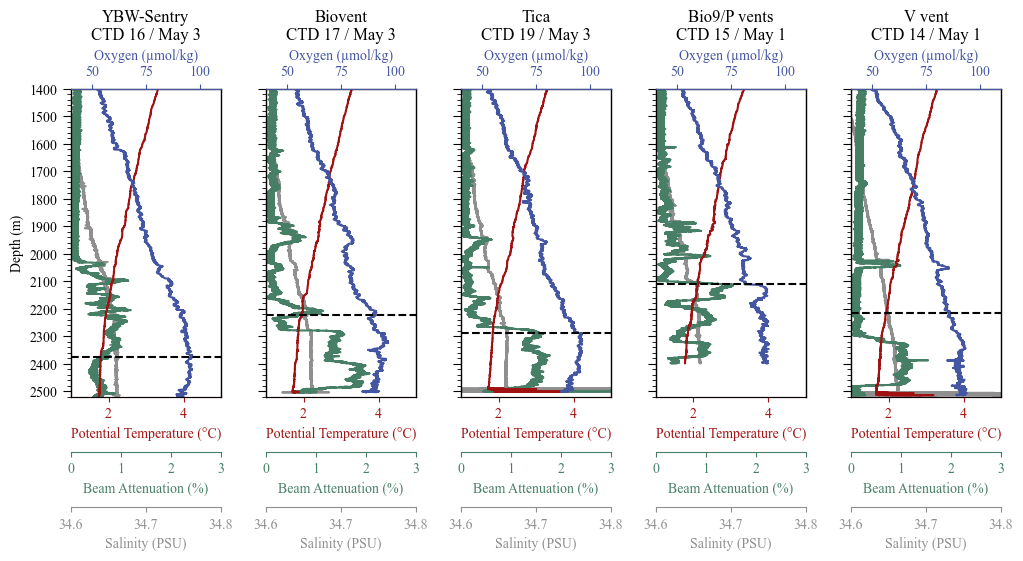

In [24]:
ctd11_p = ctd_smoothed['ctd11']
ctd13_p = ctd_smoothed['ctd13']
ctd14_p = ctd_smoothed['ctd14']
ctd15_p = ctd_smoothed['ctd15']
ctd16_p = ctd_smoothed['ctd16']
ctd17_p = ctd_smoothed['ctd17']
ctd19_p = ctd_smoothed['ctd19']

fig = plt.figure(figsize=(12, 4))
plt.rcParams['font.family'] = 'Times New Roman'

ctd_list = [
    (ctd16_p, 'ax16', '16', 1),
    (ctd17_p, 'ax17', '17', 2),
    (ctd19_p, 'ax19', '19', 3),
    (ctd15_p, 'ax15', '15', 4),
    (ctd14_p, 'ax14', '14', 5),
]

titles = {
    '16': 'YBW-Sentry\nCTD 16 / May 3',
    '17': 'Biovent\nCTD 17 / May 3',
    '19': 'Tica\nCTD 19 / May 3',
    '15': 'Bio9/P vents\nCTD 15 / May 1',
    '14': 'V vent\nCTD 14 / May 1',
}

hlines = {
    '16': 2377,
    '17': 2224,
    '19': 2287,
    '15': 2110,
    '14': 2216
}

for ctd, name, num, pos in ctd_list:
    ax_o2 = fig.add_subplot(1, 5, pos)
    ax_o2.plot(ctd['oxygenumolkg'], ctd['depth'], color=colors[0])
    ax_o2.set_ylim(2520, 1400)
    ax_o2.set_ylabel('Depth (m)')
    ax_o2.set_xlim(40, 110)
    ax_o2.xaxis.tick_top()
    ax_o2.xaxis.set_label_position('top')
    ax_o2.set_xlabel('Oxygen (µmol/kg)',color=colors[0])
    ax_o2.set_yticks([1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500])
    ax_o2.yaxis.set_minor_locator(MultipleLocator(20))
    ax_o2.tick_params(axis='y', which='minor', length=3)
    ax_o2.tick_params(axis='y', which='major', length=6)
    if pos != 1:
        ax_o2.set_ylabel('')
        ax_o2.tick_params(axis='y', which='both', labelleft=False)
    ax_o2.set_zorder(3.5)
    ax_o2.patch.set_visible(False)    

    ax_temp = ax_o2.twiny()
    ax_temp.plot(ctd['pottemp'], ctd['depth'], c=colors[1])
    ax_temp.xaxis.set_label_position('bottom')
    ax_temp.set_xlabel('Potential Temperature (°C)', color=colors[1])
    ax_temp.set_xlim(1, 5)
    ax_temp.xaxis.tick_bottom()
    ax_temp.spines['bottom'].set_color(colors[1])
    ax_temp.tick_params(axis='x', colors=colors[1])
    ax_temp.set_zorder(3.4)
    ax_temp.patch.set_visible(False)

    ax_ba = ax_o2.twiny()
    ax_ba.plot(ctd['beam_attenuation'], ctd['depth'], c=colors[2])
    ax_ba.xaxis.set_label_position('bottom')
    ax_ba.set_xlabel('Beam Attenuation (%)', color=colors[2])
    ax_ba.set_xlim(0, 3)
    ax_ba.xaxis.tick_bottom()
    ax_ba.spines['bottom'].set_position(('axes', -0.18))
    ax_ba.spines['bottom'].set_color(colors[2])
    ax_ba.tick_params(axis='x', colors=colors[2])
    ax_ba.set_zorder(3.3)
    ax_ba.patch.set_visible(False)

    ax_sal = ax_o2.twiny()
    ax_sal.plot(ctd['salinity'], ctd['depth'], c=colors[3])
    ax_sal.xaxis.set_label_position('bottom')
    ax_sal.set_xlabel('Salinity (PSU)', color=colors[3])
    ax_sal.set_xlim(34.6, 34.8)
    ax_sal.xaxis.tick_bottom()
    ax_sal.spines['bottom'].set_position(('axes', -0.36))
    ax_sal.spines['bottom'].set_color(colors[3])
    ax_sal.tick_params(axis='x', colors=colors[3])
    ax_sal.set_zorder(3.2)
    ax_sal.patch.set_visible(False)

    ax_o2.xaxis.tick_top()
    ax_o2.spines['top'].set_color(colors[0])
    ax_o2.tick_params(axis='x', colors=colors[0])
    if hlines[num] is not None:
        ax_o2.hlines(hlines[num], 40, 110, linestyles='dashed', colors='black')
    
    ax_o2.set_title(titles[num])

plt.subplots_adjust(wspace=0.3)

plt.savefig('CTD Post Eruption O2 smoothed.pdf',format='pdf', bbox_inches='tight', dpi=300)